In [41]:

####### snakemake preamble start (automatically inserted, do not edit) ########
# if (!exists("snakemake")) {
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list",
        output = "list",
        params = "list",
        wildcards = "list",
        threads = "numeric",
        log = "list",
        resources = "list",
        config = "list",
        rule = "character",
        bench_iteration = "numeric",
        scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list(
        "norm_counts_tab" = 'results/ASVs_counts_normalized.tsv' , 
        'distances_matrix' = "results/ASVs_euclidean_distance.tsv",
        "taxa" = "results/ASVs_taxa.tsv"
    ),
    output = list(),
    params = list(),
    wildcards = list(),
    threads = 1,
    log = list(),
    resources = list('tmpdir', "tmpdir" = '/tmp'),
    config = list("pathvars" = list("data_initial" = 'data/initial', "data_raw" = 'data/raw', "samples" = 'data/raw/fastq', "samples_filter" = 'data/raw/fastq/filtered', "temp" = 'data/temp', "results" = 'results', "reports" = 'results/reports', "figures" = 'results/figures')),
    rule = 'BetaDiversity',
    bench_iteration = as.numeric(NA),
    scriptdir = '/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression/workflow/steps/03_alpha_beta/notebooks',
    source = function(...){
        old_wd <- getwd()
        on.exit(setwd(old_wd), add = TRUE)

        is_url <- grepl("^https?://", snakemake@scriptdir)
        file <- ifelse(is_url, file.path(snakemake@scriptdir, ...), ...)
        if (!is_url) setwd(snakemake@scriptdir)
        source(file)
    }
)
# }
setwd('/mnt/d/Projects/03_Science_and_Education/kyh_microbio_depression');

####### snakemake preamble end #########

In [5]:
library(DESeq2); packageVersion('DESeq2')
library(vegan); packageVersion('vegan')
library(dplyr)
library(dada2)
library(phyloseq)

[1] ‘1.50.2’

[1] ‘2.7.3’


Attaching package: ‘phyloseq’


The following object is masked from ‘package:SummarizedExperiment’:

    distance


The following object is masked from ‘package:Biobase’:

    sampleNames


The following object is masked from ‘package:GenomicRanges’:

    distance


The following object is masked from ‘package:IRanges’:

    distance




In [6]:
norm_counts_tab <- read.csv(snakemake@input$norm_counts_tab,sep = "\t", row.names='X')
samples_info <- read.csv('data/initial/all_meta.csv', row.names='Run')[colnames(norm_counts_tab), ]
euc_dist_all <- as.dist(read.csv(
    snakemake@input$distances_matrix,
    sep='\t', 
    header=T,
    row.names=1
))


counts_phy <- otu_table(norm_counts_tab, taxa_are_rows = T)
samples_info_phy <- sample_data(samples_info)

phy <- phyloseq(counts_phy, samples_info_phy)

In [ ]:
deseq_counts <- phyloseq_to_deseq2(phy, ~bd_phq9_any_dep + batch + d_sex + d_age_hc_grp_10yr)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [9]:
deseq_counts <- estimateSizeFactors(deseq_counts, type = "poscounts")

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [10]:
dds <- DESeq(deseq_counts)

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing

7 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

-- replacing outliers and refitting for 3456 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- origi

In [11]:
resultsNames(dds)

[1] "Intercept"                           "bd_phq9_any_dep_PHQ.9..5_vs_PHQ.9.5"
 [3] "batch_B2_vs_B1"                      "batch_B3_vs_B1"                     
 [5] "batch_B4_vs_B1"                      "batch_B5_vs_B1"                     
 [7] "batch_B6_vs_B1"                      "batch_B7_vs_B1"                     
 [9] "d_sex_male_vs_female"                "d_age_hc_grp_10yr_45.54_vs_35.44"   
[11] "d_age_hc_grp_10yr_55.64_vs_35.44"    "d_age_hc_grp_10yr_65._vs_35.44"

In [ ]:
res <- results(dds, name='bd_phq9_any_dep_PHQ.9..5_vs_PHQ.9.5')
summary(res)
as.data.frame(head(res))


out of 15560 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 112, 0.72%
LFC < 0 (down)     : 46, 0.3%
outliers [1]       : 1440, 9.3%
low counts [2]     : 1294, 8.3%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
>ASV_1,276.5701,0.12104105,0.1727236,0.7007789,0.4834410,0.9999127
>ASV_2,209.2162,0.12255507,0.2149442,0.5701715,0.5685614,0.9999127
>ASV_3,153.6250,0.02046262,0.1827309,0.1119823,0.9108375,0.9999127
>ASV_4,153.8730,-0.01117596,0.1949327,-0.0573324,0.9542804,0.9999127
>ASV_5,142.1262,-0.11387538,0.1839084,-0.6191960,0.5357872,0.9999127
>ASV_6,138.5925,0.25290821,0.1815144,1.3933235,0.1635220,0.9999127


In [17]:
library(DESeq2)
library(phyloseq)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(tibble)
library(tidyr)
library(RColorBrewer)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [18]:
res_df <- as.data.frame(res) %>%
    rownames_to_column("ASV") %>%
    arrange(padj)

# Удаление NA
res_df <- res_df %>%
    filter(!is.na(padj))

# Категории значимости
res_df <- res_df %>%
    mutate(
        significance = case_when(
            padj < 0.05 & log2FoldChange > 1 ~ "Up",
            padj < 0.05 & log2FoldChange < -1 ~ "Down",
            TRUE ~ "NS"
        )
    )


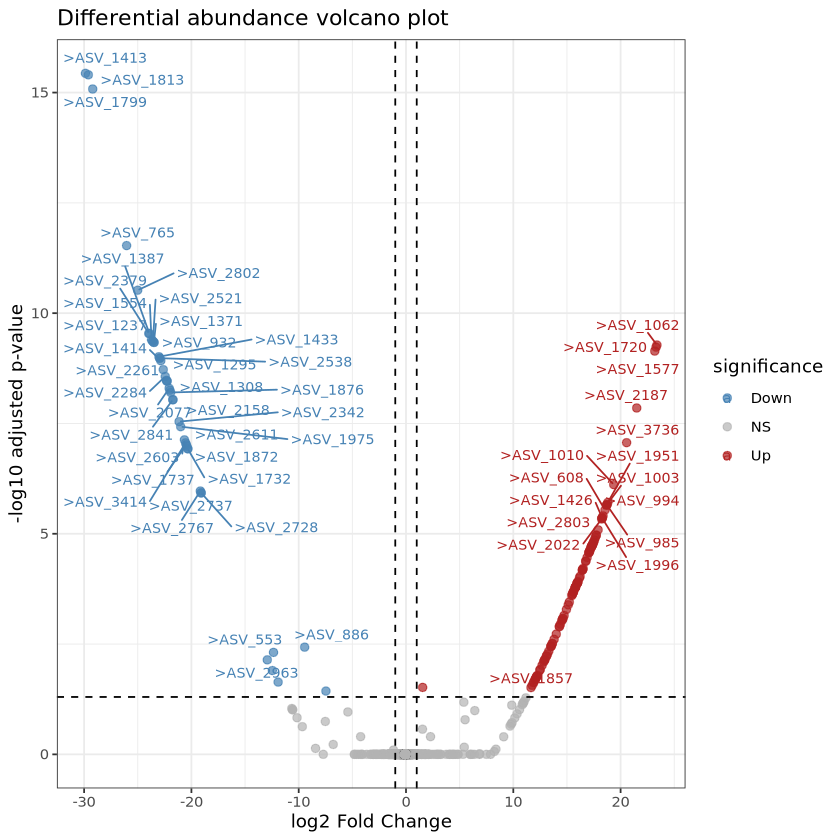

In [19]:
p_volcano <- ggplot(
    res_df,
    aes(
        x = log2FoldChange,
        y = -log10(padj),
        color = significance
    )
) +
    geom_point(alpha = 0.7, size = 2) +

    scale_color_manual(values = c(
        "Up" = "firebrick",
        "Down" = "steelblue",
        "NS" = "grey70"
    )) +

    geom_vline(xintercept = c(-1, 1),
               linetype = "dashed") +

    geom_hline(yintercept = -log10(0.05),
               linetype = "dashed") +

    geom_text_repel(
        data = subset(res_df, padj < 0.01),
        aes(label = ASV),
        size = 3,
        max.overlaps = 20
    ) +

    theme_bw() +

    labs(
        title = "Differential abundance volcano plot",
        x = "log2 Fold Change",
        y = "-log10 adjusted p-value"
    )

p_volcano

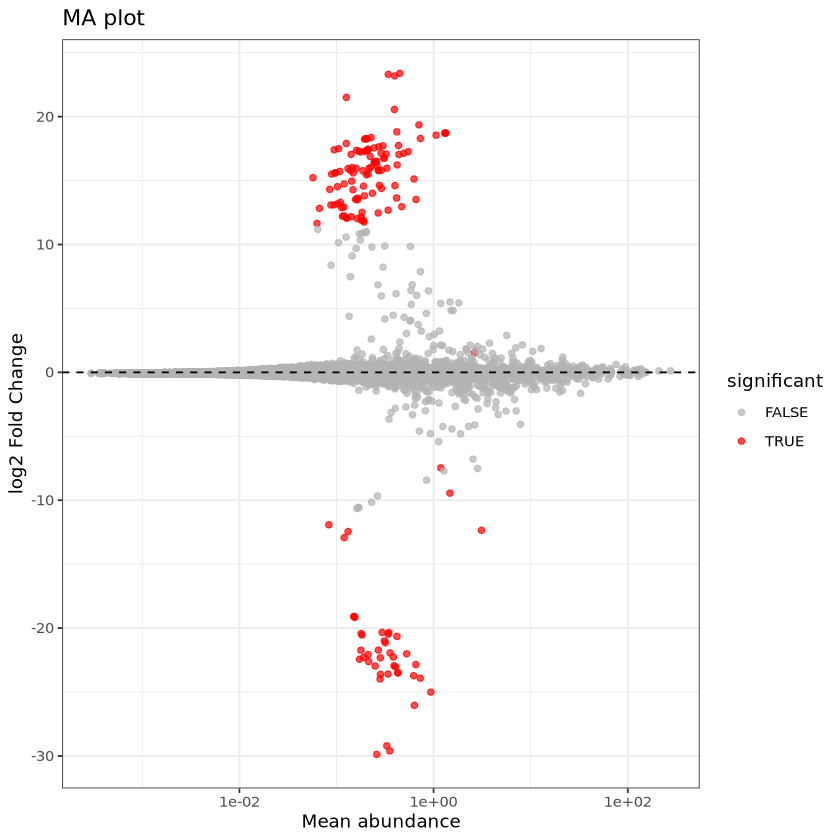

In [20]:
res_df$significant <- res_df$padj < 0.05

p_ma <- ggplot(
    res_df,
    aes(
        x = baseMean,
        y = log2FoldChange,
        color = significant
    )
) +
    geom_point(alpha = 0.7) +

    scale_x_log10() +

    scale_color_manual(values = c(
        "FALSE" = "grey70",
        "TRUE" = "red"
    )) +

    geom_hline(yintercept = 0,
               linetype = "dashed") +

    theme_bw() +

    labs(
        title = "MA plot",
        x = "Mean abundance",
        y = "log2 Fold Change"
    )

p_ma

In [21]:
sig_asv <- res_df %>%
    filter(
        padj < 0.05,
        abs(log2FoldChange) > 1
    )

write.table(
    sig_asv,
    file = "results/significant_asv.tsv",
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

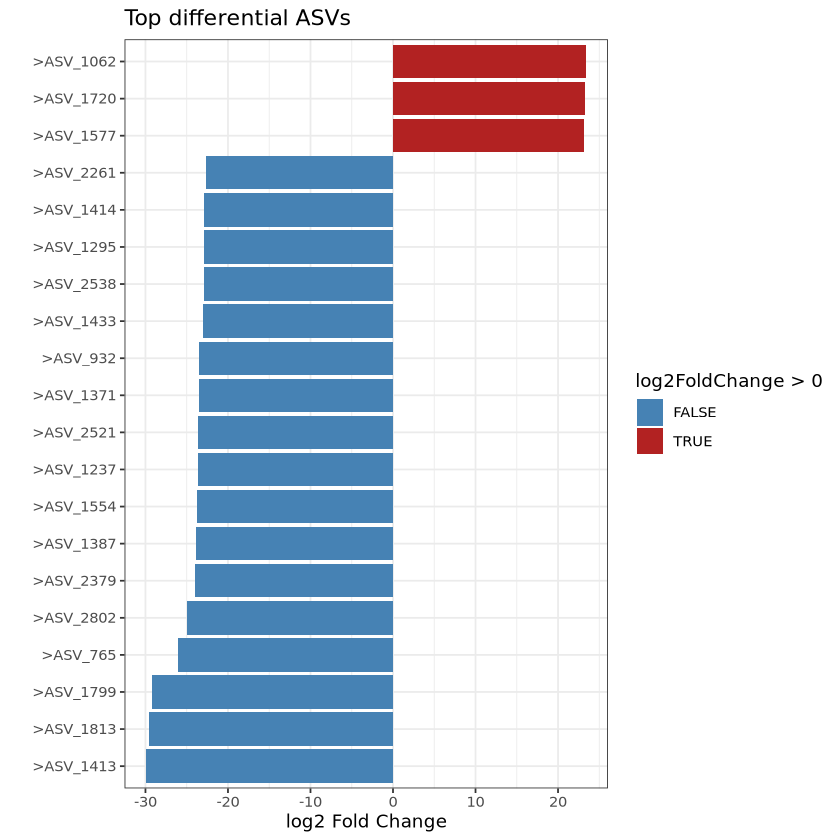

In [22]:
top_asv <- sig_asv %>%
    arrange(padj) %>%
    slice_head(n = 20)

p_bar <- ggplot(
    top_asv,
    aes(
        x = reorder(ASV, log2FoldChange),
        y = log2FoldChange,
        fill = log2FoldChange > 0
    )
) +
    geom_col() +

    coord_flip() +

    scale_fill_manual(values = c(
        "TRUE" = "firebrick",
        "FALSE" = "steelblue"
    )) +

    theme_bw() +

    labs(
        title = "Top differential ASVs",
        x = "",
        y = "log2 Fold Change"
    )

p_bar

In [ ]:
vsd <- varianceStabilizingTransformation(dds)
top_heatmap_asv <- sig_asv %>%
    arrange(padj) %>%
    slice_head(n = 30) %>%
    pull(ASV)

mat <- assay(vsd)[top_heatmap_asv, ]

# Z-score scaling
mat <- t(scale(t(mat)))

annotation_df <- data.frame(
    Depression = colData(dds)$bd_phq9_any_dep
)

rownames(annotation_df) <- colnames(mat)

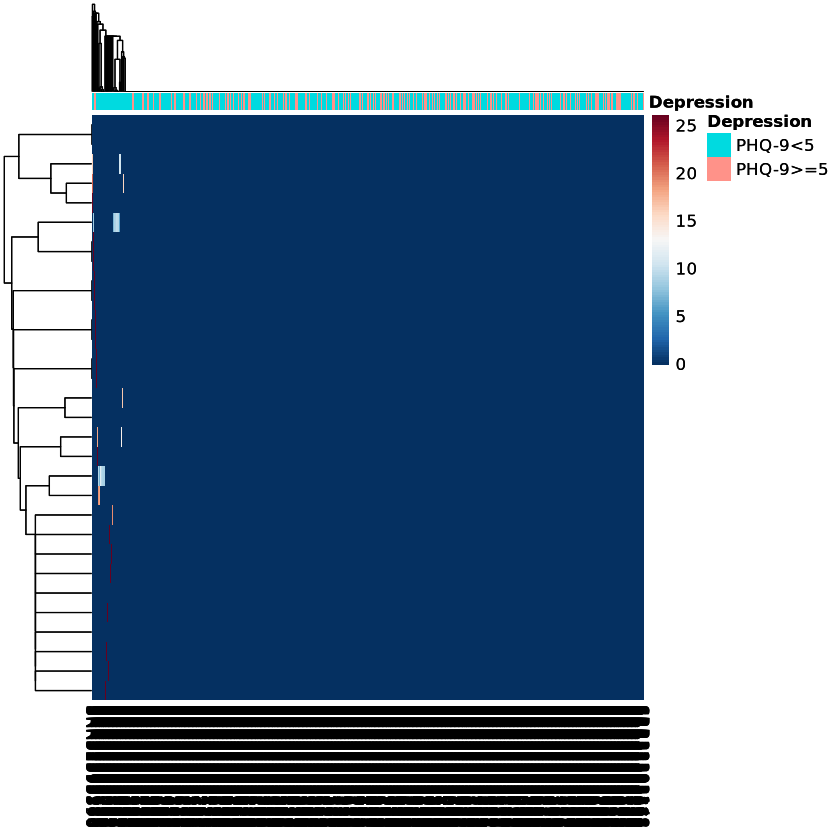

In [45]:
p <- pheatmap(
    mat,
    annotation_col = annotation_df,
    show_rownames = FALSE,
    clustering_method = "ward.D2",
    fontsize_col = 10,
    color = colorRampPalette(
        rev(brewer.pal(n = 11, name = "RdBu"))
    )(100),
    # filename = "results/top_asv_heatmap.png",
    width = 8,
    height = 10
)
show(p)

In [42]:
snakemake@input

$norm_counts_tab
[1] "results/ASVs_counts_normalized.tsv"

$distances_matrix
[1] "results/ASVs_euclidean_distance.tsv"

$taxa
[1] "results/ASVs_taxa.tsv"

In [43]:
taxa <- read.csv(snakemake@input$taxa, sep='\t', header=T, row.names=1)

In [44]:
tax_df <- as.data.frame(taxa)

sig_asv_tax <- sig_asv %>%
    left_join(
        tax_df %>%
            rownames_to_column("ASV"),
        by = "ASV"
    )